In [1]:
from sklearn.datasets import load_wine
from sklearn.metrics import roc_auc_score, accuracy_score, classification_report
from sklearn.model_selection import train_test_split
from tabpfn import TabPFNClassifier

# Simplest model

In [2]:

# Load Wine dataset
X, y = load_wine(return_X_y=True)

# Train/test split (stratified to keep class distribution)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Initialize and fit TabPFN classifier
clf = TabPFNClassifier()
clf.fit(X_train, y_train)

# Predict probabilities and compute macro ROC AUC (one-vs-rest)
probs = clf.predict_proba(X_test)
roc_auc = roc_auc_score(y_test, probs, multi_class="ovr", average="macro")
print("Macro ROC AUC (OvR):", roc_auc)

# Predict labels and compute accuracy
preds = clf.predict(X_test)
print("Accuracy:", accuracy_score(y_test, preds))

# Detailed performance report
print("\nClassification report:\n", classification_report(y_test, preds))


Macro ROC AUC (OvR): 1.0
Accuracy: 1.0

Classification report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        18
           1       1.00      1.00      1.00        21
           2       1.00      1.00      1.00        15

    accuracy                           1.00        54
   macro avg       1.00      1.00      1.00        54
weighted avg       1.00      1.00      1.00        54



In [3]:
X.shape

(178, 13)

In [4]:
y.shape

(178,)

# with Stratified sample

In [5]:
from sklearn.datasets import load_wine
from sklearn.model_selection import StratifiedKFold, StratifiedShuffleSplit
from sklearn.metrics import roc_auc_score, accuracy_score, roc_curve, auc
from sklearn.preprocessing import label_binarize
import numpy as np
import matplotlib.pyplot as plt

n_splits = 10
random_state = 0
train_subsample = 0.35   # Use only a fraction of each training fold to make the task harder

# ---- Load data ----
X, y = load_wine(return_X_y=True)
classes = np.unique(y)

cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)

auc_scores, acc_scores = [], []
worst_fold_data = None   # to store y_test + probs for the lowest-AUC fold

for fold_idx, (tr, te) in enumerate(cv.split(X, y), 1):
    X_tr, y_tr = X[tr], y[tr]
    X_te, y_te = X[te], y[te]

    # Subsample the training portion to make the task harder 
    if train_subsample < 1.0:
        sss = StratifiedShuffleSplit(n_splits=1, train_size=train_subsample,
                                     random_state=random_state + fold_idx)
        tr_sub, _ = next(sss.split(X_tr, y_tr))
        X_tr, y_tr = X_tr[tr_sub], y_tr[tr_sub]

    # Fit TabPFN
    clf = TabPFNClassifier()  # e.g., TabPFNClassifier(n_estimators=32, device="cpu"/"cuda")
    clf.fit(X_tr, y_tr)

    # Predict
    probs = clf.predict_proba(X_te)      # shape: [n_test, n_classes]
    preds = clf.predict(X_te)

    # Metrics
    auc_macro = roc_auc_score(y_te, probs, multi_class="ovr", average="macro")
    acc = accuracy_score(y_te, preds)

    auc_scores.append(auc_macro)
    acc_scores.append(acc)

    print(f"Fold {fold_idx:02d}: AUC_macro(OvR) = {auc_macro:.4f} | Acc = {acc:.4f}")

    # Track worst fold
    if (worst_fold_data is None) or (auc_macro < worst_fold_data["auc_macro"]):
        worst_fold_data = {
            "fold_idx": fold_idx,
            "y_test": y_te,
            "probs": probs,
            "auc_macro": auc_macro
        }

# ---- Summary ----
print("\nSummary over folds")
print(f"AUC_macro(OvR): mean = {np.mean(auc_scores):.4f} ± {np.std(auc_scores):.4f}")
print(f"Accuracy      : mean = {np.mean(acc_scores):.4f} ± {np.std(acc_scores):.4f}")


Fold 01: AUC_macro(OvR) = 1.0000 | Acc = 1.0000
Fold 02: AUC_macro(OvR) = 0.9905 | Acc = 0.9444
Fold 03: AUC_macro(OvR) = 0.9913 | Acc = 0.8889
Fold 04: AUC_macro(OvR) = 1.0000 | Acc = 0.9444
Fold 05: AUC_macro(OvR) = 1.0000 | Acc = 0.9444
Fold 06: AUC_macro(OvR) = 1.0000 | Acc = 1.0000
Fold 07: AUC_macro(OvR) = 1.0000 | Acc = 1.0000
Fold 08: AUC_macro(OvR) = 1.0000 | Acc = 0.9444
Fold 09: AUC_macro(OvR) = 1.0000 | Acc = 1.0000
Fold 10: AUC_macro(OvR) = 1.0000 | Acc = 1.0000

Summary over folds
AUC_macro(OvR): mean = 0.9982 ± 0.0036
Accuracy      : mean = 0.9667 ± 0.0369


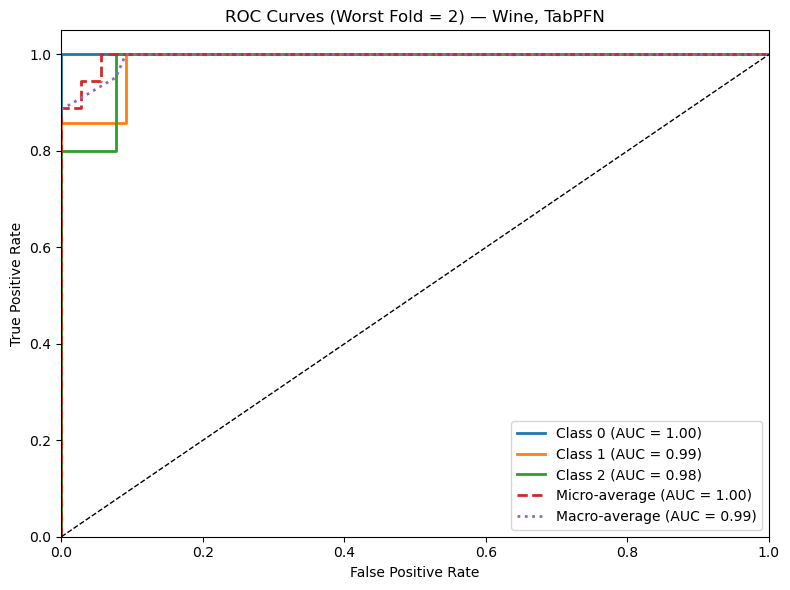

In [6]:
# ---- Plot ROC for the worst (lowest AUC) fold ----
y_test = worst_fold_data["y_test"]
probs = worst_fold_data["probs"]
fold_id = worst_fold_data["fold_idx"]

# Binarize labels for OvR ROC
y_test_bin = label_binarize(y_test, classes=classes)
n_classes = y_test_bin.shape[1]

fpr, tpr, roc_auc = {}, {}, {}
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Micro-average
fpr["micro"], tpr["micro"], _ = roc_curve(y_test_bin.ravel(), probs.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

# Macro-average (average TPR over a common FPR grid)
all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))
mean_tpr = np.zeros_like(all_fpr)
for i in range(n_classes):
    mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
mean_tpr /= n_classes
fpr["macro"] = all_fpr
tpr["macro"] = mean_tpr
roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])

plt.figure(figsize=(8, 6))

# Plot per-class ROC
for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], lw=2, label=f"Class {classes[i]} (AUC = {roc_auc[i]:.2f})")

# Plot micro and macro averages
plt.plot(fpr["micro"], tpr["micro"], lw=2, linestyle="--",
         label=f"Micro-average (AUC = {roc_auc['micro']:.2f})")
plt.plot(fpr["macro"], tpr["macro"], lw=2, linestyle=":",
         label=f"Macro-average (AUC = {roc_auc['macro']:.2f})")

# Chance line
plt.plot([0, 1], [0, 1], "k--", lw=1)

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curves (Worst Fold = {fold_id}) — Wine, TabPFN")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


# Benchmarking with other classifier 

In [7]:
# !pip install -q scipy  # uncomment if scipy isn't installed
from sklearn.datasets import load_wine
from sklearn.model_selection import StratifiedKFold, StratifiedShuffleSplit
from sklearn.metrics import roc_auc_score, accuracy_score, brier_score_loss
from sklearn.preprocessing import label_binarize
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.svm import SVC
from tabpfn import TabPFNClassifier
from scipy.stats import wilcoxon
import numpy as np
import matplotlib.pyplot as plt
from sklearn.multiclass import OneVsRestClassifier

# ------------------------------
# Helpers
# ------------------------------
def multiclass_brier(y_true, proba, classes):
    # Mean Brier over classes (one-vs-rest)
    Y = label_binarize(y_true, classes=classes)
    return np.mean((Y - proba) ** 2)

def evaluate_models(X, y, models, n_splits=10, random_state=0, train_subsample=0.35):
    classes = np.unique(y)
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    splits = list(skf.split(X, y))  # reuse same folds for all models

    results = {name: {"auc": [], "acc": [], "brier": []} for name in models}

    for name, make_model in models.items():
        for fold_idx, (tr, te) in enumerate(splits, 1):
            X_tr, y_tr = X[tr], y[tr]
            X_te, y_te = X[te], y[te]

            # Stratified subsample of training fold to make it harder
            if train_subsample < 1.0:
                sss = StratifiedShuffleSplit(n_splits=1, train_size=train_subsample,
                                             random_state=random_state + fold_idx)
                tr_sub, _ = next(sss.split(X_tr, y_tr))
                X_tr, y_tr = X_tr[tr_sub], y_tr[tr_sub]

            clf = make_model()
            clf.fit(X_tr, y_tr)

            # Probabilities (needed for AUC & Brier)
            proba = clf.predict_proba(X_te)
            preds = np.argmax(proba, axis=1)

            auc_macro = roc_auc_score(y_te, proba, multi_class="ovr", average="macro")
            acc = accuracy_score(y_te, preds)
            brier = multiclass_brier(y_te, proba, classes)

            results[name]["auc"].append(auc_macro)
            results[name]["acc"].append(acc)
            results[name]["brier"].append(brier)

        # Per-model summary
        print(f"\n{name}")
        for k in ["auc", "acc", "brier"]:
            vals = np.array(results[name][k])
            mean, std = vals.mean(), vals.std()
            lab = {"auc": "AUC_macro(OvR)", "acc": "Accuracy", "brier": "Brier"}[k]
            print(f"  {lab}: {mean:.4f} ± {std:.4f}")

    return results, classes

def summarize_and_test(results):
    import numpy as np
    from scipy.stats import wilcoxon, binomtest

    # Pick best non-TabPFN baseline by mean AUC
    names = list(results.keys())
    baselines = [n for n in names if n != "TabPFN"]
    auc_means = {n: np.mean(results[n]["auc"]) for n in names}
    best_base = max(baselines, key=lambda n: auc_means[n])

    # Paired per-fold AUCs and differences
    t_auc = np.asarray(results["TabPFN"]["auc"], dtype=float)
    b_auc = np.asarray(results[best_base]["auc"], dtype=float)
    diff = t_auc - b_auc

    wins  = int(np.sum(diff > 0))
    losses = int(np.sum(diff < 0))
    ties   = int(np.sum(diff == 0))
    n_eff  = wins + losses   # ties excluded

    print(f"\nPaired comparison on per-fold AUCs (TabPFN vs {best_base})")
    print(f"  wins={wins}, losses={losses}, ties={ties}, n_eff={n_eff}")

    if n_eff == 0:
        print("  All folds are ties; statistical test not applicable.")
        return best_base

    # Wilcoxon on non-zero differences (no ties). Use exact when feasible.
    mode = "exact" if n_eff <= 25 else "auto"
    try:
        stat, p_w = wilcoxon(
            diff[diff != 0],
            zero_method="wilcox",
            alternative="greater",
            mode=mode
        )
    except Exception:
        # Fallback to normal approximation if exact not available
        stat, p_w = wilcoxon(
            diff[diff != 0],
            zero_method="wilcox",
            alternative="greater",
            mode="approx"
        )
        mode = "approx"

    print(f"  Wilcoxon (ties removed, {mode}): W={stat:.3f}, p={p_w:.5f}")

    # Sign test (binomial) as a small-n, tie-robust check
    p_s = binomtest(wins, n_eff, p=0.5, alternative="greater").pvalue
    print(f"  Sign test: p={p_s:.5f}")

    return best_base


def data_efficiency_curve(X, y, best_baseline, fracs=(0.1, 0.2, 0.35, 0.5, 0.75, 1.0),
                          n_splits=10, random_state=0):
    classes = np.unique(y)
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    splits = list(skf.split(X, y))

    def run_for(model_fn, frac):
        aucs = []
        for i, (tr, te) in enumerate(splits, 1):
            X_tr, y_tr = X[tr], y[tr]
            X_te, y_te = X[te], y[te]
            if frac < 1.0:
                sss = StratifiedShuffleSplit(n_splits=1, train_size=frac,
                                             random_state=random_state + i)
                tr_sub, _ = next(sss.split(X_tr, y_tr))
                X_tr, y_tr = X_tr[tr_sub], y_tr[tr_sub]
            clf = model_fn()
            clf.fit(X_tr, y_tr)
            proba = clf.predict_proba(X_te)
            aucs.append(roc_auc_score(y_te, proba, multi_class="ovr", average="macro"))
        return np.mean(aucs), np.std(aucs)

    tabpfn_means, tabpfn_stds = [], []
    base_means, base_stds = [], []
    for f in fracs:
        m, s = run_for(lambda: TabPFNClassifier(), f)
        tabpfn_means.append(m); tabpfn_stds.append(s)
        m, s = run_for(best_baseline, f)
        base_means.append(m); base_stds.append(s)

    # Plot (mean ± std) AUC vs training fraction
    plt.figure(figsize=(7,5))
    plt.errorbar(fracs, tabpfn_means, yerr=tabpfn_stds, marker="o", label="TabPFN")
    plt.errorbar(fracs, base_means,   yerr=base_stds,   marker="s", label="Best baseline")
    plt.xlabel("Training fraction used per fold")
    plt.ylabel("Macro ROC AUC (OvR)")
    plt.title("Data Efficiency — Wine (10× Stratified CV)")
    plt.legend()
    plt.tight_layout()
    plt.show()

In [8]:
# ------------------------------
# Run
# ------------------------------
X, y = load_wine(return_X_y=True)

models = {
    "TabPFN": lambda: TabPFNClassifier(),
    "LogReg":lambda: OneVsRestClassifier(LogisticRegression(max_iter=5000)),
    "kNN-5" : lambda: KNeighborsClassifier(n_neighbors=5),
    "GBC"   : lambda: GradientBoostingClassifier(random_state=0),
    "SVC-RBF": lambda: SVC(kernel="rbf", probability=True, random_state=0)
}

results, classes = evaluate_models(
    X, y, models, n_splits=10, random_state=0, train_subsample=0.35
)


TabPFN
  AUC_macro(OvR): 0.9982 ± 0.0036
  Accuracy: 0.9667 ± 0.0369
  Brier: 0.0145 ± 0.0164

LogReg
  AUC_macro(OvR): 0.9937 ± 0.0096
  Accuracy: 0.9493 ± 0.0390
  Brier: 0.0245 ± 0.0148

kNN-5
  AUC_macro(OvR): 0.8653 ± 0.0470
  Accuracy: 0.6578 ± 0.0760
  Brier: 0.1297 ± 0.0276

GBC
  AUC_macro(OvR): 0.9887 ± 0.0178
  Accuracy: 0.9320 ± 0.0497
  Brier: 0.0358 ± 0.0167

SVC-RBF
  AUC_macro(OvR): 0.8530 ± 0.0614
  Accuracy: 0.6977 ± 0.0903
  Brier: 0.1251 ± 0.0199


In [9]:
best_base_name = summarize_and_test(results)


Paired comparison on per-fold AUCs (TabPFN vs LogReg)
  wins=4, losses=0, ties=6, n_eff=4
  Wilcoxon (ties removed, exact): W=10.000, p=0.06250
  Sign test: p=0.06250


In [ ]:
# Choose the factory for the best baseline for the efficiency curve
best_baseline_factory = {
    "LogReg": lambda: OneVsRestClassifier(LogisticRegression(max_iter=5000)),
    "kNN-5": lambda: KNeighborsClassifier(n_neighbors=5),
    "GBC": lambda: GradientBoostingClassifier(random_state=0),
    "SVC-RBF": lambda: SVC(kernel="rbf", probability=True, random_state=0)
}[best_base_name]

data_efficiency_curve(X, y, best_baseline_factory)